##Import Dataset


In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("KhoLinkSamSetCuaQan - KhoLinkSamSetCuaQan.csv")

# Làm sạch: bỏ dấu ';' thừa ở tên cột và ở giá trị (do file CSV có nhiều cột rỗng)
df.columns = df.columns.str.replace(';', '', regex=False).str.strip()
df['Labels'] = df['Labels'].astype(str).str.replace(';', '', regex=False).str.strip()

# Chuyển Labels về số, bỏ dòng lỗi/null rồi ép về số nguyên (0/1, không phải 0.0/1.0)
df['Labels'] = pd.to_numeric(df['Labels'], errors='coerce')
df = df.dropna(subset=['Labels'])
df['Labels'] = df['Labels'].astype(int)

df.shape

(9164, 2)

In [3]:
df.head()


,Url,Labels
0,https://courses.ut.edu.vn/mod/quiz/attempt.php...,1
1,https://bruno.taweb.net.br/asd,0
2,https://claim-fantom-72h.com/FS24fvV243AQQ,0
3,https://m.ani4u.org/xem-anime/strawberry-panic...,1
4,https://ilovedevelopers.com/data/9NF28238VF7/i...,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9164 entries, 0 to 9164
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Url     9164 non-null   object
 1   Labels  9164 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 214.8+ KB


xử lý trùng

In [5]:
#đếm số dòng trùng
print("Số dòng trùng nhau",df.duplicated().sum())

Số dòng trùng nhau 34


In [6]:
#xóa dòng trùng
df.drop_duplicates(inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9130 entries, 0 to 9164
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Url     9130 non-null   object
 1   Labels  9130 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 214.0+ KB


xử lý hàng bị null

In [8]:
print(df.isnull().sum())

Url       0
Labels    0
dtype: int64


In [9]:
df.dropna(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9130 entries, 0 to 9164
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Url     9130 non-null   object
 1   Labels  9130 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 214.0+ KB


##Feature Extraction

In [11]:
import re #tìm kiếm trả về kiểu bool
from urllib.parse import urlparse
import math
from collections import Counter # Added this line

def calculate_entropy(s):
    if not s:
        return 0
    counts = Counter(s)
    total_length = len(s)
    entropy = 0
    for count in counts.values():
        probability = count / total_length
        entropy -= probability * math.log2(probability)
    return entropy

def extract_url_features(url):
    # Normalize and protect against NaN or non-string inputs
    if pd.isna(url):
        url = ""
    else:
        url = str(url)
    parsed = urlparse(url)
    hostname = parsed.hostname or ""

    ip_pattern = re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}\b')
    shorteners = ['bit.ly', 'tinyurl', 'goo.gl', 't.co', 'ow.ly', 'buff.ly']
    tlds = [".com", ".org", ".net", ".edu", ".gov", ".us", ".uk", ".ca", ".au", ".de",
            ".fr", ".it", ".es", ".nl", ".se", ".ch", ".jp", ".cn", ".kr", ".sg", ".hk",
            ".tw", ".in", ".br", ".mx", ".ru", ".pl", ".vn", ".id", ".th", ".my", ".ph", ".za"]

    features = {
        'qty_dot': url.count('.'),
        'qty_underline': url.count('_'),
        'ip_present': 1 if ip_pattern.search(url) else 0,
        'qty_and': url.count('&'),
        'qty_questionmark': url.count('?'),
        'path_length': len(parsed.path),
        'qty_equal': url.count('='),
        'qty_at': url.count('@'),
        'qty_digits': sum(c.isdigit() for c in url),
        'qty_hyphen': url.count('-'),
        'qty_plus': url.count('+'),
        'qty_asterisk': url.count('*'),
        'qty_slash': url.count('/'),
        'qty_dollar': url.count('$'),
        'url_length': len(url),
        'hostname_length': len(hostname),
        'shortener_present': 1 if any(s in hostname for s in shorteners) else 0,
        'qty_uppercase': sum(c.isupper() for c in url),
        'qty_exclamation': url.count('!'),
        'qty_space': url.count(' '),
        'qty_hastag': url.count('#'),
        'qty_tilde': url.count('~'),
        'qty_comma': url.count(','),
        'qty_percent': url.count('%'),
        'tld_present': 1 if any(t in url for t in tlds) else 0,
        'port_present': 1 if parsed.port else 0,
        'entropy': calculate_entropy(url)
    }
    return features

results = [extract_url_features(url) for url in df['Url'].fillna('')]
df_features = pd.DataFrame(results)
df_features['Label'] = df['Labels'].reset_index(drop=True)

df_features.head(350)

,qty_dot,qty_underline,ip_present,qty_and,qty_questionmark,path_length,qty_equal,qty_at,qty_digits,qty_hyphen,...,qty_exclamation,qty_space,qty_hastag,qty_tilde,qty_comma,qty_percent,tld_present,port_present,entropy,Label
0,4,0,0,2,1,21,3,0,14,0,...,0,0,0,0,0,0,1,0,4.746852,1
1,3,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,1,0,3.831402,0
2,1,0,0,0,0,14,0,0,7,2,...,0,0,0,0,0,0,1,0,4.558519,0
3,5,5,1,0,1,27,1,0,30,5,...,0,0,0,0,0,0,1,0,5.747270,1
4,2,0,0,0,1,28,1,0,8,0,...,0,0,0,0,0,0,1,0,4.694465,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,1,0,0,0,0,5,0,0,0,0,...,0,0,0,0,0,0,1,0,3.784184,0
346,4,0,0,0,1,61,2,0,13,1,...,0,0,1,0,0,0,1,0,5.399595,1
347,1,0,0,0,0,1,0,0,0,2,...,0,0,0,0,0,0,1,0,4.018082,0
348,4,0,0,0,1,35,1,1,11,1,...,0,0,0,0,0,0,1,0,4.869767,0


Trực quan hóa

In [12]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\Quoc An\AppData\Local\Temp\ipykernel_8560\863052780.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


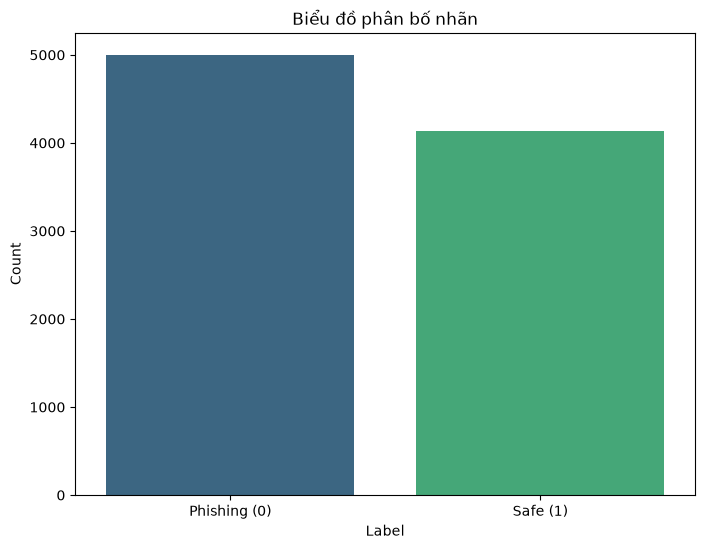

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts of each unique value in the 'Labels' column
label_counts = df['Labels'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Biểu đồ phân bố nhãn')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Phishing (0)', 'Safe (1)']) # Assuming 0 and 1 are the labels
plt.show()

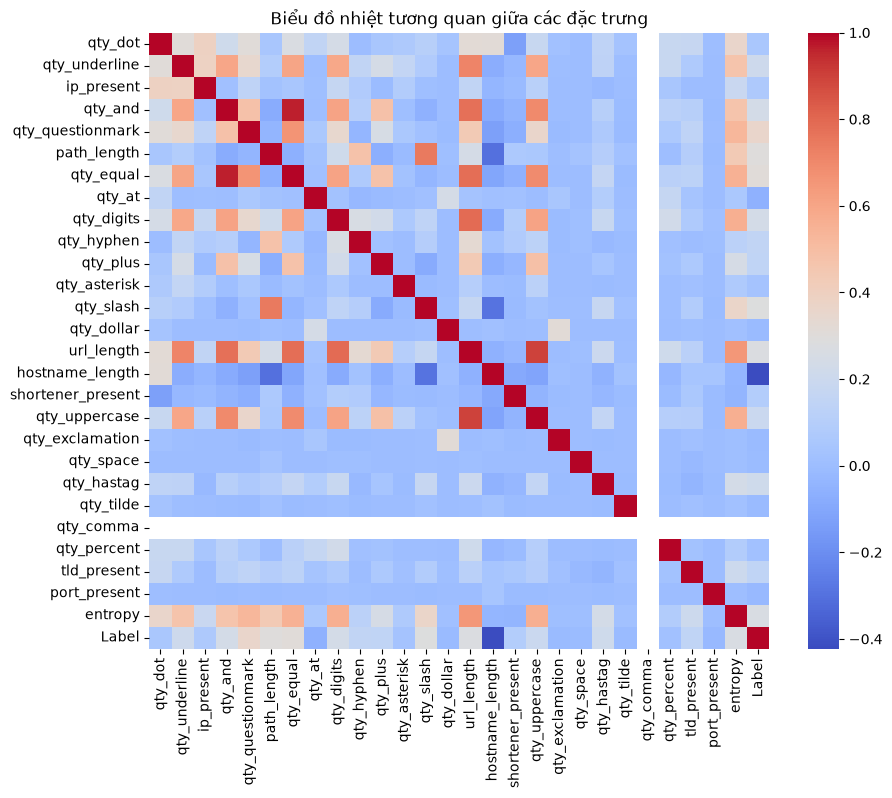

In [14]:
# Tính ma trận tương quan
corr = df_features.corr()

# Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm') # annot=False cho đỡ rối mắt vì nhiều biến
plt.title("Biểu đồ nhiệt tương quan giữa các đặc trưng")
plt.show()

Text(0.5, 1.0, 'So sánh Entropy giữa URL An toàn và Độc hại')

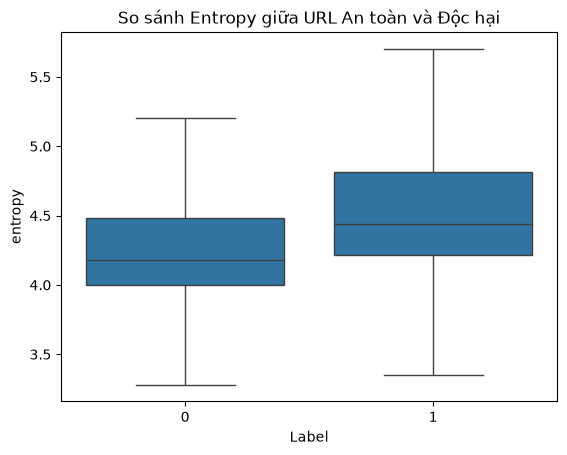

In [15]:
sns.boxplot(data=df_features, x='Label', y='entropy', showfliers=False)
plt.title("So sánh Entropy giữa URL An toàn và Độc hại")

#Split train, test

In [16]:
from sklearn.model_selection import train_test_split

X = df_features.drop(['Label'], axis=1)  #Lấy cột đặc trưng
Y = df_features['Label']  #Lấy cột nhãn

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [17]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (7304, 27)
X_test shape: (1826, 27)


##Chuẩn hóa đặc trưng

ví dụ: cột length_url giá trị tối đa là 80. cột nb_dots giá trị tối đa chỉ có 3 -> chênh lệch như vậy dẫn đến sai, chuyển về 1 đơn vị đo

In [18]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

#Chuẩn hóa và học trên dữ liệu train
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Train Machine Learning models

In [19]:
from sklearn.ensemble import RandomForestClassifier
                                    #100 cây          chia cho đều   dùng cPU cho nó mạnh
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, Y_train)

score_rf = model_rf.score(X_train_scaled, Y_train)
print(f"Random Forest Accuracy: {score_rf}")

Random Forest Accuracy: 0.9982201533406353


##Đánh giá

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Kiểm tra, đánh giá trên tập test
Y_predict = model_rf.predict(X_test_scaled)

#Thông số hiệu suất
print(f"Accuracy: {accuracy_score(Y_test, Y_predict)}")
print(f"Precision: {precision_score(Y_test, Y_predict)}")
print(f"Recall: {recall_score(Y_test, Y_predict)}")
print(f"F1 Score: {f1_score(Y_test, Y_predict)}")

Accuracy: 0.9282584884994524
Precision: 0.9223416965352449
Recall: 0.9212410501193318
F1 Score: 0.9217910447761194


##Train XGBoost để so sánh

In [21]:
from xgboost import XGBClassifier

# Train XGBoost trên cùng dữ liệu đã chuẩn hóa
model_xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
model_xgb.fit(X_train_scaled, Y_train)

# Dự đoán trên tập test
Y_predict_xgb = model_xgb.predict(X_test_scaled)

# Thông số hiệu suất
print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(Y_test, Y_predict_xgb)}")
print(f"Precision: {precision_score(Y_test, Y_predict_xgb)}")
print(f"Recall: {recall_score(Y_test, Y_predict_xgb)}")
print(f"F1 Score: {f1_score(Y_test, Y_predict_xgb)}")

=== XGBoost ===
Accuracy: 0.9288061336254108
Precision: 0.919431279620853
Recall: 0.9260143198090692
F1 Score: 0.9227110582639715


        Model  Accuracy  Precision   Recall  F1 Score
Random Forest  0.928258   0.922342 0.921241  0.921791
      XGBoost  0.928806   0.919431 0.926014  0.922711


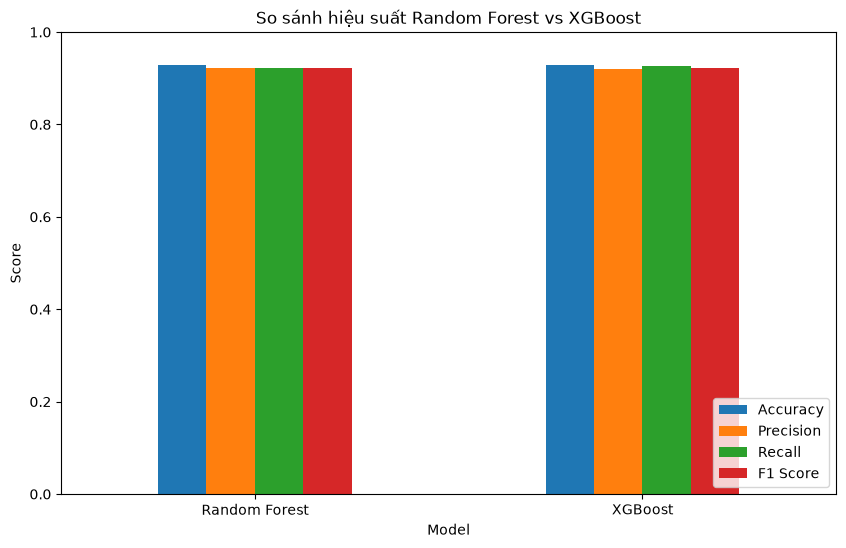

In [22]:
# So sánh hiệu suất Random Forest và XGBoost
import pandas as pd

so_sanh = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy':  [accuracy_score(Y_test, Y_predict),      accuracy_score(Y_test, Y_predict_xgb)],
    'Precision': [precision_score(Y_test, Y_predict),     precision_score(Y_test, Y_predict_xgb)],
    'Recall':    [recall_score(Y_test, Y_predict),        recall_score(Y_test, Y_predict_xgb)],
    'F1 Score':  [f1_score(Y_test, Y_predict),            f1_score(Y_test, Y_predict_xgb)],
})

print(so_sanh.to_string(index=False))

# Vẽ biểu đồ cột so sánh
so_sanh.set_index('Model').plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('So sánh hiệu suất Random Forest vs XGBoost')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

##Lưu model để dùng cho web app

In [23]:
import joblib

# Lưu mô hình XGBoost và bộ chuẩn hóa để web app (app.py) dùng lại
joblib.dump(model_xgb, "model_xgb.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Đã lưu model_xgb.pkl và scaler.pkl")

Đã lưu model_xgb.pkl và scaler.pkl
